# Weather-object datasets

This notebook shows how to inspect, visualise, and do simple analysis using weather-object datasets.

Weather object datasets are avaialble under `data/weatherfatures.era5`. Each dataset is stored as monthly netcdf files.

| Weather system | Variable | Path |
|:---|:---|:---|
| Surface cyclone | `INPUT` | `mincl/cdf/<year>/C<year>_<month>.nc')` |
| Surface anticyclone | `FLAG` | `maxcl/cdf/<year>/A<year>_<month>.nc')` |
| Front at 700 hPa | `FRONT` | `fronts/cdf.700hPa/<year>/F<year>_<month>.nc')` |
| Front at 850 hPa | `FRONT` | `fronts/cdf.850hPa/<year>/F<year>_<month>.nc')` |
| Warm conveyor belt - inflow | `GT800` | `wcb/cdf.1hourly/<year>/hit_<year>_<month>.nc')` |
| Warm conveyor belt - ascent | `MIDTROP` | `wcb/cdf.1hourly/<year>/hit_<year>_<month>.nc')` |
| Warm conveyor belt - outflow | `LT400` | `wcb/cdf.1hourly/<year>/hit_<year>_<month>.nc')` |

In [86]:
import xarray as xr
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

The function used to assign coordiantes for weather object dataset

In [87]:
def assign_weatherfeature_coords(ds):
    # suqeeze
    ds = ds.squeeze()
    
    # get names of y and x dims
    y_dim = list(ds.dims)[1]
    x_dim = list(ds.dims)[2]
    
    # get numbers of y and x dims
    ny = ds.sizes[y_dim]
    nx = ds.sizes[x_dim]
    
    # assign coords
    lat_vals = np.arange(-90, 90.5, 0.5)
    lon_vals = -180 + 0.5 * np.arange(nx)
    ds = ds.assign_coords({y_dim: (y_dim, lat_vals)})
    ds = ds.assign_coords({x_dim: (x_dim, lon_vals)})
    
    # rename y- and x-coordiante as lat and lon
    ds = ds.rename({y_dim: 'latitude', x_dim: 'longitude'})

    # check longitude
    if ds.longitude.size != 720:
        ds = ds.sel(longitude=np.arange(-180, 180, .5))

    return ds

In [88]:
# directories
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
datadir = f'{workdir}/data/weatherfeatures.era5'

In [89]:
# one month exmaple
year = 2018; month = 1

# cyclone
cyclone = xr.open_dataset(f'{datadir}/mincl/cdf/{year}/C{year}_{str(month).zfill(2)}.nc')
cyclone = assign_weatherfeature_coords(cyclone).sel(latitude=slice(-55, -9),longitude=slice(110, 155))


# anticyclone
anticyclone = xr.open_dataset(f'{datadir}/maxcl/cdf/{year}/A{year}_{str(month).zfill(2)}.nc')
anticyclone = assign_weatherfeature_coords(anticyclone).sel(latitude=slice(-55, -9),longitude=slice(110, 155))


# front
front = xr.open_dataset(f'{datadir}/fronts/cdf.700hPa/{year}/F{year}_{str(month).zfill(2)}.nc')
front = assign_weatherfeature_coords(front).sel(latitude=slice(-55, -9),longitude=slice(110, 155))


# wcb
wcb = xr.open_dataset(f'{datadir}/wcb/cdf.1hourly/{year}/hit_{year}_{str(month).zfill(2)}.nc')
wcb = assign_weatherfeature_coords(wcb).sel(latitude=slice(-55, -9),longitude=slice(110, 155))

At an instantaneous timestep

Text(0.5, 1.0, '2018-01-01T12')

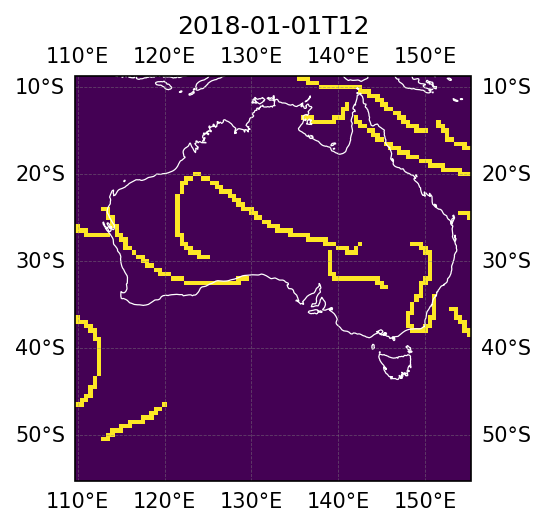

In [90]:
single = front['FRONT'].isel(time=12)
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
# plot object
single.plot(ax=ax, transform=datacrs, add_colorbar=False)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='w', lw=.6)
#ax.set_extent([-180, 180, -90, 90], crs=datacrs)
ax.set_title(f'{str(single.time.values)[0:13]}')

Climatology

Text(0.5, 1.0, 'Monthly climatology')

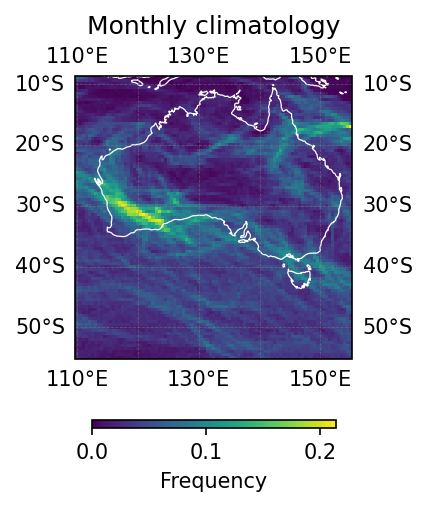

In [91]:
clim = front['FRONT'].mean('time')
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
clim.plot(ax=ax, transform=datacrs, 
          cbar_kwargs={"shrink": 0.3,
                       "aspect": 30,
                       "label": "Frequency",
                       "orientation": "horizontal"}
         )
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='w', lw=.6)
#ax.set_extent([-180, 180, -90, 90], crs=datacrs)
ax.set_title('Monthly climatology')

subset and occurrence over a region

In [92]:
box = dict(
    latitude=slice(-40, -30),
    longitude=slice(140, 150),
) # 441 gridpoints

cyclone_ts = (
    cyclone.sel(**box)["INPUT"].sum(("latitude", "longitude"))
)/441

anticyclone_ts = (
    anticyclone.sel(**box)["FLAG"].sum(("latitude", "longitude"))
)/441

front_ts = (
    front.sel(**box)["FRONT"].sum(("latitude", "longitude"))
)/441

wcb_ts = (
    wcb.sel(**box)["MIDTROP"].sum(("latitude", "longitude"))
)/441

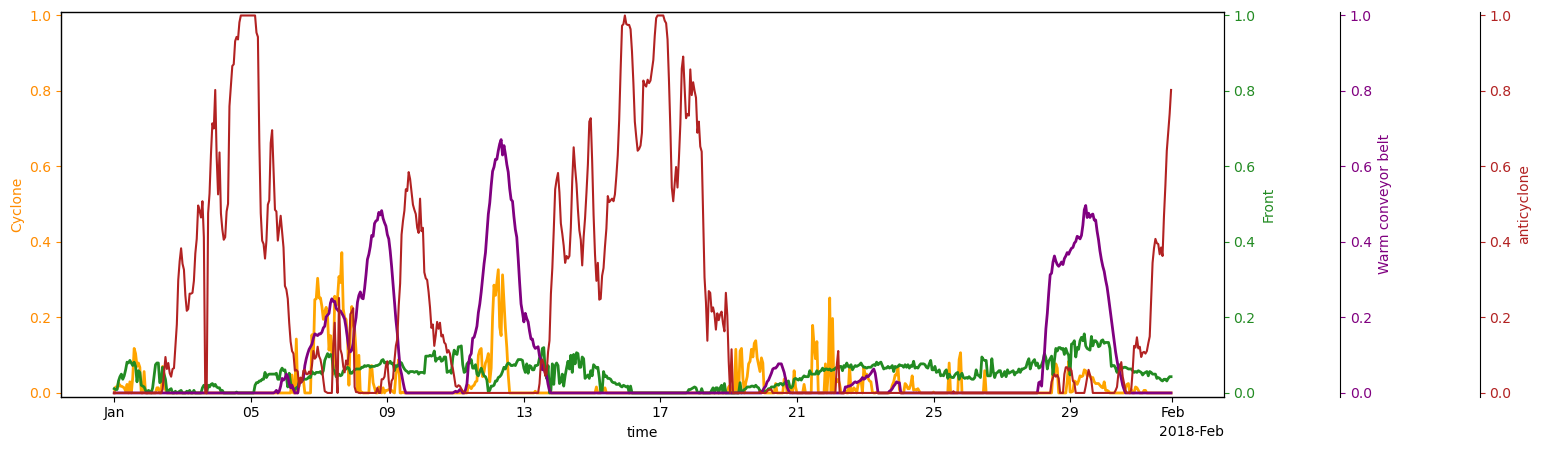

In [93]:
fig, ax1 = plt.subplots(figsize=(15, 5), dpi=100)
cyclone_ts.plot(ax=ax1, color='orange', linewidth=2)
ax2 = plt.twinx()
front_ts.plot(ax=ax2, color='forestgreen', linewidth=2)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.1))
wcb_ts.plot(ax=ax3, color='purple', linewidth=2)

ax4 = ax1.twinx()
ax4.spines["right"].set_position(("axes", 1.22))
anticyclone_ts.plot(ax=ax4, color='firebrick')

ax1.set_ylim(-0.01, 1.01)
ax1.set_ylabel('Cyclone', color='darkorange')
ax1.tick_params(axis="y", colors='darkorange')
ax2.set_ylim(-0.01, 1.01)
ax2.set_ylabel('Front', color='forestgreen')
ax2.tick_params(axis="y", colors='forestgreen')
ax3.set_ylim(-.01, 1.01)
ax3.set_ylabel('Warm conveyor belt', color='purple')
ax3.tick_params(axis="y", colors='purple')
ax4.set_ylim(-.01, 1.01)
ax4.set_ylabel('anticyclone', color='firebrick')
ax4.tick_params(axis="y", colors='firebrick')